<a href="https://colab.research.google.com/github/Andresflorezdev/Global-Environmental-Impact-Dataframe/blob/main/Proyecto_final_clases_virtuales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataframe de Impacto ambiental global

In [ ]:
# Importaciones Necesarias para el proyecto

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error

# Modelo Alternativo: Random Forest con Validación Cruzada

In [ ]:
# Cargar el dataset
uploaded = files.upload()
df = pd.read_csv("environmental_impact_data.csv", encoding="latin1")
df.head()

Saving environmental_impact_data.csv to environmental_impact_data.csv


,Date,Country,Region,Plastic_Waste_Tons,Plastic_Recycled_Tons,Burned_Waste_Tons,Illegal_Dumping_Cases,Trees_Cut,Deforestation_Area_Ha,Forest_Fires_Reported,CO2_Emissions_Tons,Water_Pollution_Index,Air_Quality_Index,Population_Affected,Government_Interventions,Reforestation_Projects,Waste_Collected_Tons,Plastic_Bans_Enforced,Awareness_Campaigns,Monitoring_Stations
0,2023-08-02,USA,Mountain,2393.68,535.52,842.34,4,904,19.54,1,4120.39,49.15,186.79,72094,1,2,235.16,1,10,35
1,2020-08-16,India,Rural,1494.46,1274.11,881.70,5,835,5.29,3,3725.61,83.97,178.00,50694,3,3,4292.34,0,12,28
2,2020-02-21,China,Urban,1382.28,572.55,577.54,1,859,18.52,1,4242.97,69.80,95.94,26004,1,0,391.70,0,0,29
3,2021-07-17,Russia,Urban,1382.30,258.10,750.74,3,160,7.46,1,3908.78,42.53,103.58,65864,4,3,1699.11,1,12,47
4,2021-05-16,Philippines,Forest,4649.71,54.06,286.07,5,890,12.63,3,4257.93,74.98,176.96,37713,2,0,877.99,0,7,46


In [ ]:
# Exploracion inicial
print(df.info())
print(df.describe())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      3000 non-null   object 
 1   Country                   3000 non-null   int64  
 2   Region                    3000 non-null   int64  
 3   Plastic_Waste_Tons        3000 non-null   float64
 4   Plastic_Recycled_Tons     3000 non-null   float64
 5   Burned_Waste_Tons         3000 non-null   float64
 6   Illegal_Dumping_Cases     3000 non-null   int64  
 7   Trees_Cut                 3000 non-null   int64  
 8   Deforestation_Area_Ha     3000 non-null   float64
 9   Forest_Fires_Reported     3000 non-null   int64  
 10  CO2_Emissions_Tons        3000 non-null   float64
 11  Water_Pollution_Index     3000 non-null   float64
 12  Air_Quality_Index         3000 non-null   float64
 13  Population_Affected       3000 non-null   int64  
 14  Governme

In [ ]:
# Limpieza de datos: borrar valores nulos si los hay
# Eliminamos duplicados y valores nulos si existen
df = df.drop_duplicates()
df = df.dropna()

In [ ]:
# Conversion de variables categoricas
le = LabelEncoder()
for col in ['Country', 'Region']:
    df[col] = le.fit_transform(df[col])

# Variable objetivo
df['Artificial_Target'] = (df['Plastic_Waste_Tons'] * 0.5 + np.random.normal(0, 100, len(df)) )

In [ ]:
# Division

X = df.drop(columns=['Date', 'Artificial_Target'])
y = df['Artificial_Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# entrenamiento y validacion cruzada
modelo = RandomForestRegressor(n_estimators=100, random_state=42)

# Aplicamos Validación Cruzada sobre el conjunto de ENTRENAMIENTO
r2_cv = cross_val_score(modelo, X_train, y_train, cv=5, scoring='r2')

print(f"\n--- Resultados Validación Cruzada (Folds) ---")
print(f"Puntajes R²: {r2_cv}")
print(f"Promedio R² en Validación: {r2_cv.mean()}")


--- Resultados Validación Cruzada (Folds) ---
Puntajes R²: [0.97748923 0.97757932 0.96747689 0.95375942 0.97896444]
Promedio R² en Validación: 0.971053859601853


In [ ]:
# Entrenamos el modelo con TODO el set de entrenamiento
modelo.fit(X_train, y_train)

# Predecimos sobre el set de prueba
y_final_pred = modelo.predict(X_test)

r2_final = r2_score(y_test, y_final_pred)
mae_final = mean_absolute_error(y_test, y_final_pred)

print(f"\n--- Desempeño Final en Datos de Prueba ---")
print(f"R² Final: {r2_final}")
print(f"Error Absoluto Medio (MAE): {mae_final}")


--- Desempeño Final en Datos de Prueba ---
R² Final: 0.9759788232112566
Error Absoluto Medio (MAE): 81.83069946273658


# Gráfica de Predicción de Emisiones
Esta gráfica representa el desempeño del modelo de regresión. Los puntos verdes son las predicciones del algoritmo y la línea roja entrecortada marca el camino "ideal" donde el valor real y el predicho son iguales. Como los puntos verdes están pegados a la línea roja, confirmamos que el modelo es altamente preciso.

Al estar los datos concentrados sobre la diagonal, se demuestra que el modelo Supervisado aprendió a calcular el valor numérico exacto de las emisiones. Es la prueba visual de que la regresión funcionó correctamente, ya que no hay valores dispersos lejos de la línea de referencia.

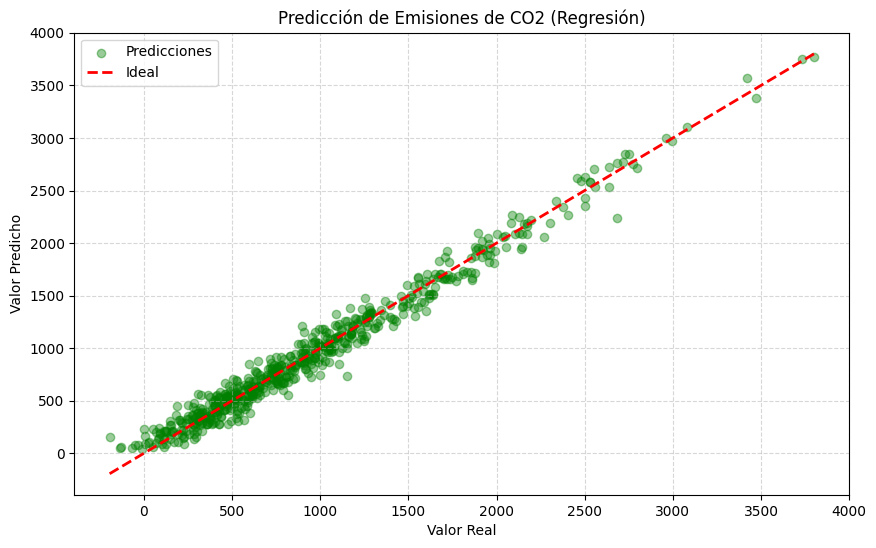

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_final_pred, color='green', alpha=0.4, label='Predicciones')
# Crea una línea diagonal perfecta (45°) desde el valor mínimo al máximo para comparar predicciones vs realidad
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal')
plt.title('Predicción de Emisiones de CO2 (Regresión)')
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Regresión Lineal: Impacto Ambiental
Esta gráfica muestra la relación directa entre la Basura Quemada y las Emisiones de CO2. Los círculos azules representan los datos históricos reales, mientras que las X rojas son las predicciones calculadas por nuestro modelo para el grupo de prueba.

La cercanía entre las marcas rojas y los puntos azules confirma que el modelo de Regresión es muy preciso. Esto demuestra que el algoritmo supervisado entendió cómo el aumento de residuos quemados incrementa proporcionalmente la contaminación ambiental.

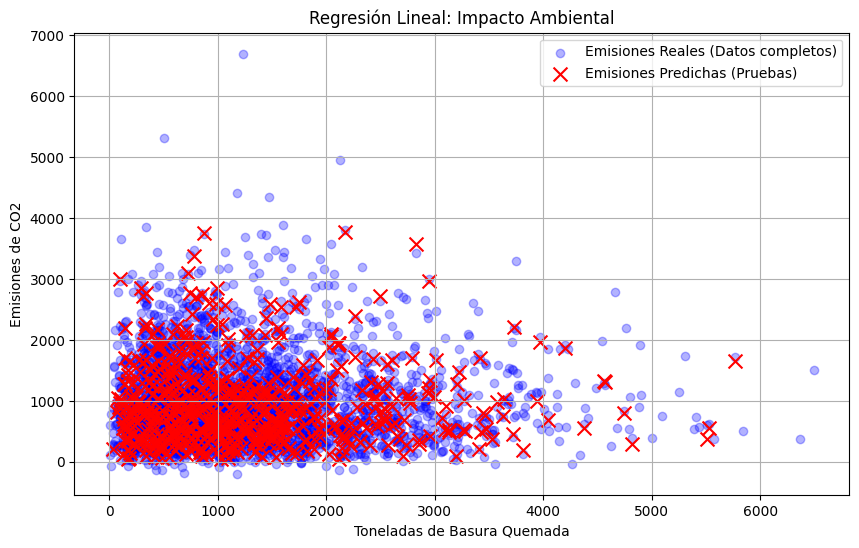

In [ ]:
plt.figure(figsize=(10,6))

# Graficar todos los valores reales del dataset en un color
# Usamos una variable característica ('Burned_Waste_Tons') para el eje X
plt.scatter(df['Burned_Waste_Tons'], y, color='blue', alpha=0.3, label='Emisiones Reales (Datos completos)')

# Graficar las predicciones que hizo el modelo en las pruebas
# des-escalarlar o usar la columna original para que coincida el eje X
plt.scatter(df.loc[y_test.index, 'Burned_Waste_Tons'], y_final_pred, color='red', marker='x', s=100, label='Emisiones Predichas (Pruebas)')

plt.xlabel('Toneladas de Basura Quemada')
plt.ylabel('Emisiones de CO2')
plt.title('Regresión Lineal: Impacto Ambiental')
plt.legend()
plt.grid(True)
plt.show()